# **Part A — Supervised model + metrics (20 marks)**
## Q1. Random Forest on Wine Dataset
### Steps:
1. Load the dataset (X, y). Split into train/test (80/20), with fixed random_state.
2. Train a RandomForestClassifier with:
- n_estimators=200
- random_state fixed
3. Print a classification report.
4. Plot a confusion matrix visualization.

In [16]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Load the dataset
X, y= load_wine(return_X_y=True)


x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    stratify = y,
    random_state = 42
)

# Train RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 200, random_state =42)
rf.fit(x_train, y_train)

# Prdictions
y_pred = rf.predict(x_test)

# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



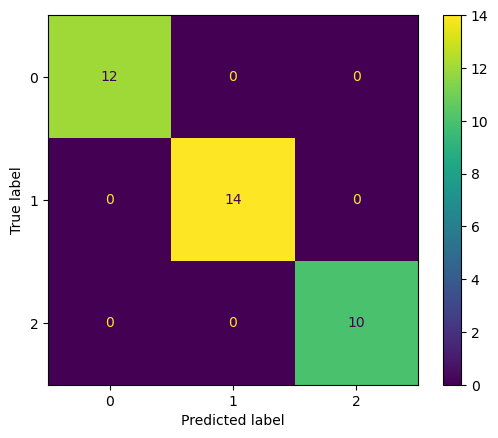

In [17]:
# confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# **Part B — Cross-validation (10 marks)**
## Q2. 5-fold Cross-validation for Random Forest
### Steps:
1. Perform 5-fold stratified cross-validation using accuracy.
2. Print:
- The 5 scores
- Mean
- Standard deviation

In [18]:

from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

rf = RandomForestClassifier(n_estimators =200, random_state = 42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf, X,y,cv = cv , scoring = 'accuracy')

print('Scores: ', scores)
print('Mean: ', np.mean(scores))
print('Std : ', np.std(scores))

Scores:  [0.97222222 1.         0.97222222 0.94285714 1.        ]
Mean:  0.9774603174603176
Std :  0.021299434518521104


# **Part C — Boosting (5 marks)**
## Q3. AdaBoost vs Random Forest
### Steps:
1. Train AdaBoostClassifier using decision stumps (max_depth=1) with n_estimators=100.
2. Print the test accuracy for AdaBoost and Random Forest.

In [19]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [20]:
# Train AdaBoostClassifier
ada = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(max_depth = 1),
    n_estimators = 100,
    random_state = 42
)

ada.fit(x_train, y_train)
y_pred_ada = ada.predict(x_test)

In [22]:
# accuracy
ada_acc = accuracy_score(y_test, y_pred_ada)
rf_acc = accuracy_score(y_test, y_pred)

print('AdaBoost Acc: ',ada_acc)
print('RandomForest Accr: ', rf_acc)

AdaBoost Acc:  0.9166666666666666
RandomForest Accr:  1.0


# **Part D — Clustering + Evaluation (5 marks)**
## Q4. DBSCAN on Iris Dataset
### Steps:
1. Load Iris X only. Scale it.
2. Run DBSCAN with eps=0.6 and min_samples=5.
3. Print:
- Number of clusters found (ignore noise label -1)
- Number of noise points

In [23]:

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Load Iris dataset
iris = load_iris()
X_iris = iris.data

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

# Run DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=5)
dbscan.fit(X_scaled)

# Print the number of clusters and noise points
n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise = list(dbscan.labels_).count(-1)
print('Number of clusters found:', n_clusters)
print('Number of noise points:', n_noise)


Number of clusters found: 2
Number of noise points: 26
